In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.4 MB/s eta 0:00:001.9 MB/s eta 0:00:01


In [5]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.3.0-py3-none-macosx_12_0_arm64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-macosx_12_0_arm64.whl (2.4 MB)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [7]:
dataset = pd.read_excel("Expense_Dataset_With_NextMonthExpense.xlsx")

In [8]:
print(dataset.head())

print(dataset.info())

print(dataset.describe())

print(dataset.isnull().sum())

print("Duplicate Rows :", dataset.duplicated().sum())

  User_ID  Year  Month  Monthly_Income     Bills  Education  Entertainment  \
0  U00001  2025      1       146919.89  18181.21   24989.66        4224.07   
1  U00001  2025      2       136686.15   2962.98    1506.22        4859.21   
2  U00001  2025      3       139109.12  39399.34    3482.08        8255.10   
3  U00001  2025      4       137749.26   2944.78   21537.40        2469.06   
4  U00001  2025      5       143849.44   4196.16   20147.00        7091.05   

       Food    Health  Shopping  ...    Travel  Total_Expense   Savings  \
0   1286.79   2855.04   6148.05  ...  18804.57       83974.51  62945.38   
1  33775.74   4605.29   8628.82  ...  14322.37       82862.49  53823.66   
2   4296.83   4024.55    451.19  ...  11290.27       82554.05  56555.07   
3   1411.24   6061.04  38263.22  ...   2498.67       84221.71  53527.55   
4  15472.78  15524.34  11867.61  ...   1463.44       87388.16  56461.28   

   Savings_Rate  Expense_Ratio  Average_Daily_Expense  \
0        0.4284        

In [9]:
dataset = dataset.drop_duplicates()

In [11]:
dataset = dataset.ffill()

In [12]:
month_order = {

    "January":1,
    "February":2,
    "March":3,
    "April":4,
    "May":5,
    "June":6,
    "July":7,
    "August":8,
    "September":9,
    "October":10,
    "November":11,
    "December":12

}

dataset["Month"] = (
    dataset["Month"]
    .astype(str)
    .str.strip()
    .str.title()
)

dataset["Month"] = dataset["Month"].map(month_order)

In [13]:
encoder = LabelEncoder()

dataset["Spending_Profile"] = encoder.fit_transform(
    dataset["Spending_Profile"]
)

In [14]:
X = dataset.drop(columns=[

    "User_ID",

    "NextMonthExpense"

])

y = dataset["NextMonthExpense"]

print(X.shape)

print(y.shape)

(110000, 19)
(110000,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

In [16]:
models = {

    "Random Forest": RandomForestRegressor(

        n_estimators=300,

        random_state=42,

        n_jobs=-1

    ),

    "Gradient Boosting": GradientBoostingRegressor(

        n_estimators=300,

        learning_rate=0.05,

        random_state=42

    ),

    "XGBoost": XGBRegressor(

        objective="reg:squarederror",

        n_estimators=300,

        learning_rate=0.05,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        n_jobs=-1

    )

}

In [18]:
from sklearn.impute import SimpleImputer

# Handle missing values
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

results = []
trained_models = {}

for name, model in models.items():

    print("=" * 60)
    print(name)

    # Train model
    model.fit(X_train_imputed, y_train)

    # Predict
    predictions = model.predict(X_test_imputed)

    # Evaluation
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    mape = mean_absolute_percentage_error(y_test, predictions)

    print("MAE  :", round(mae, 2))
    print("RMSE :", round(rmse, 2))
    print("R²   :", round(r2, 4))
    print("MAPE :", round(mape * 100, 2), "%")

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "MAPE": mape * 100
    })

    trained_models[name] = model

/opt/anaconda3/envs/ict/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['Month']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/envs/ict/lib/python3.12/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['Month']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Random Forest
MAE  : 5542.31
RMSE : 7892.32
R²   : 0.9778
MAPE : 5.46 %
Gradient Boosting
MAE  : 5397.08
RMSE : 7731.03
R²   : 0.9787
MAPE : 5.3 %
XGBoost
MAE  : 5407.35
RMSE : 7740.33
R²   : 0.9786
MAPE : 5.32 %


In [19]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by="R²",

    ascending=False

)

results_df

,Model,MAE,RMSE,R²,MAPE
1,Gradient Boosting,5397.078935,7731.030196,0.978675,5.303749
2,XGBoost,5407.350480,7740.329321,0.978623,5.318291
0,Random Forest,5542.312876,7892.317657,0.977776,5.456832


In [21]:
results_df.to_csv(

    "model_comparison.csv",

    index=False

)

In [22]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(best_model_name)

Gradient Boosting


In [23]:
from sklearn.model_selection import RandomizedSearchCV

In [24]:
params = {

    "n_estimators":[300,500,700],

    "max_depth":[3,4,5,6,8],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "subsample":[0.7,0.8,0.9,1.0],

    "colsample_bytree":[0.7,0.8,0.9,1.0],

    "min_child_weight":[1,3,5],

    "gamma":[0,0.1,0.2,0.3],

    "reg_alpha":[0,0.1,1],

    "reg_lambda":[1,2,5]

}

In [25]:
xgb = XGBRegressor(

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)

In [26]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=params,

    n_iter=30,

    cv=5,

    scoring="r2",

    random_state=42,

    verbose=2,

    n_jobs=-1

)

In [27]:
random_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [28]:
print("Best Parameters")

print(random_search.best_params_)

Best Parameters
{'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 1.0}


In [29]:
print("Best Cross Validation R²")

print(random_search.best_score_)

Best Cross Validation R²
0.979063953299514


In [30]:
best_model = random_search.best_estimator_

In [31]:
predictions = best_model.predict(

    X_test

)

In [32]:
mae = mean_absolute_error(

    y_test,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        predictions

    )

)

r2 = r2_score(

    y_test,

    predictions

)

mape = mean_absolute_percentage_error(

    y_test,

    predictions

)

print("="*60)

print("Tuned XGBoost Results")

print("="*60)

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R² :", round(r2,4))

print("MAPE :", round(mape*100,2), "%")

Tuned XGBoost Results
MAE : 5381.84
RMSE : 7701.69
R² : 0.9788
MAPE : 5.3 %


In [33]:
results_df.loc[len(results_df)] = [

    "Tuned XGBoost",

    mae,

    rmse,

    r2,

    mape*100

]

results_df = results_df.sort_values(

    by="R²",

    ascending=False

)

results_df

,Model,MAE,RMSE,R²,MAPE
3,Tuned XGBoost,5381.844142,7701.694127,0.978836,5.301868
1,Gradient Boosting,5397.078935,7731.030196,0.978675,5.303749
2,XGBoost,5407.350480,7740.329321,0.978623,5.318291
0,Random Forest,5542.312876,7892.317657,0.977776,5.456832


In [34]:
results_df.to_csv(

    "model_comparison.csv",

    index=False

)

In [35]:
import joblib

joblib.dump(

    best_model,

    "expense_prediction_model.pkl"

)

joblib.dump(

    X.columns.tolist(),

    "feature_names.pkl"

)

print("Best Model Saved Successfully")

Best Model Saved Successfully
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.03, max_depth=6, min_child_weight=5, n_estimators=300, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   2.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=700, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   4.9s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=8, min_child_weight=3, n_estimators=300, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=8, min_child_weight=5, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.9; total time=   5.4s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=8, min_child_weight=5, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.9; total time=   5.6s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.03, max_depth=3, min_child_weight=5, n_estimato

In [36]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
11,Total_Expense,0.728993
15,Average_Daily_Expense,0.254477
2,Monthly_Income,0.004275
18,Spending_Profile,0.003328
14,Expense_Ratio,0.001416
13,Savings_Rate,0.001232
12,Savings,0.001046
17,Transaction_Count,0.000594
16,Weekend_Spending_Percentage,0.000587
6,Food,0.000559


In [37]:
importance.to_csv(

    "feature_importance.csv",

    index=False

)

print("Feature Importance Saved")

Feature Importance Saved


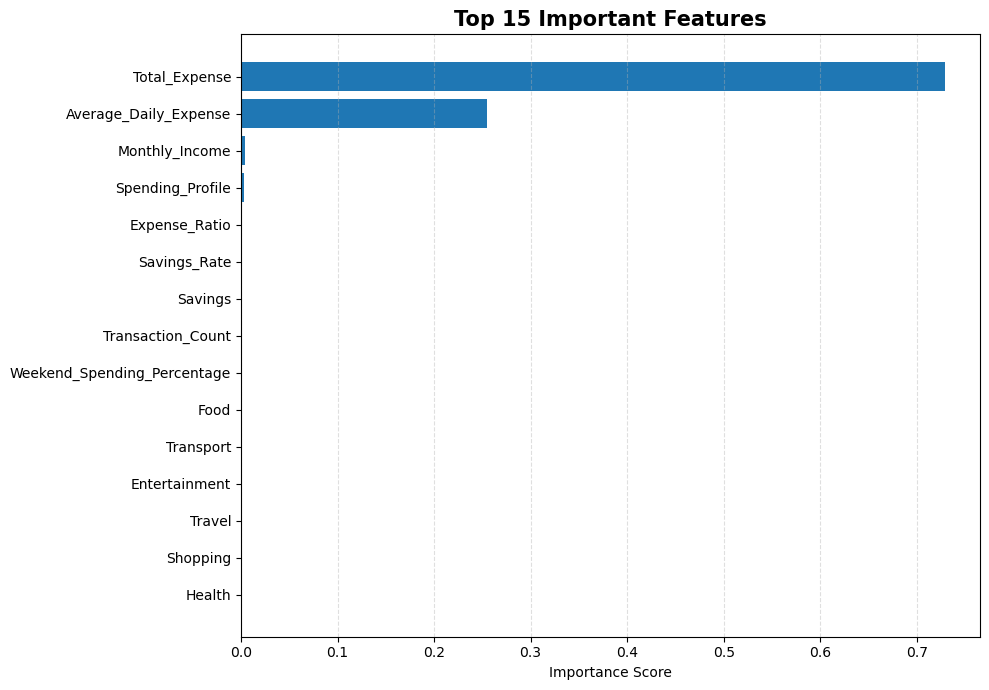

In [38]:
import matplotlib.pyplot as plt

top15 = importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(

    top15["Feature"],

    top15["Importance"]

)

plt.gca().invert_yaxis()

plt.title(

    "Top 15 Important Features",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Importance Score")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(

    "feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

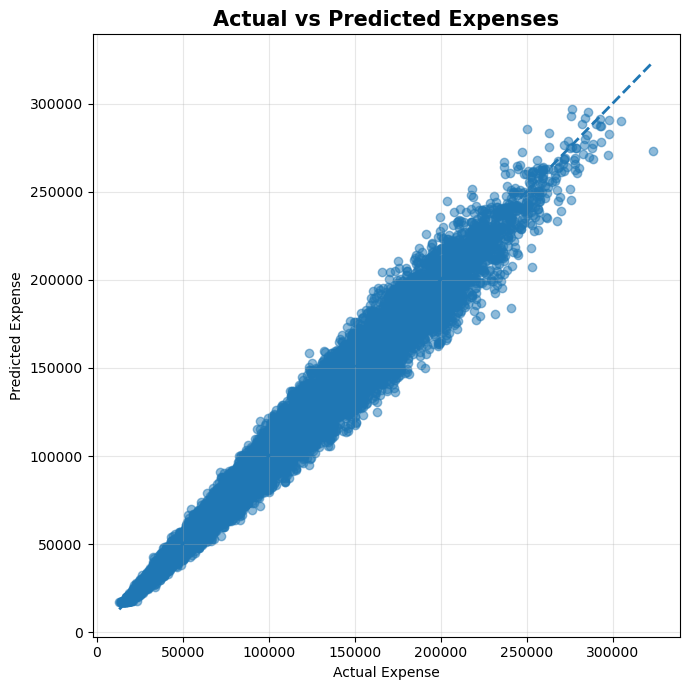

In [39]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    predictions,

    alpha=0.5

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    linestyle="--",

    linewidth=2

)

plt.title(

    "Actual vs Predicted Expenses",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Actual Expense")

plt.ylabel("Predicted Expense")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    "actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

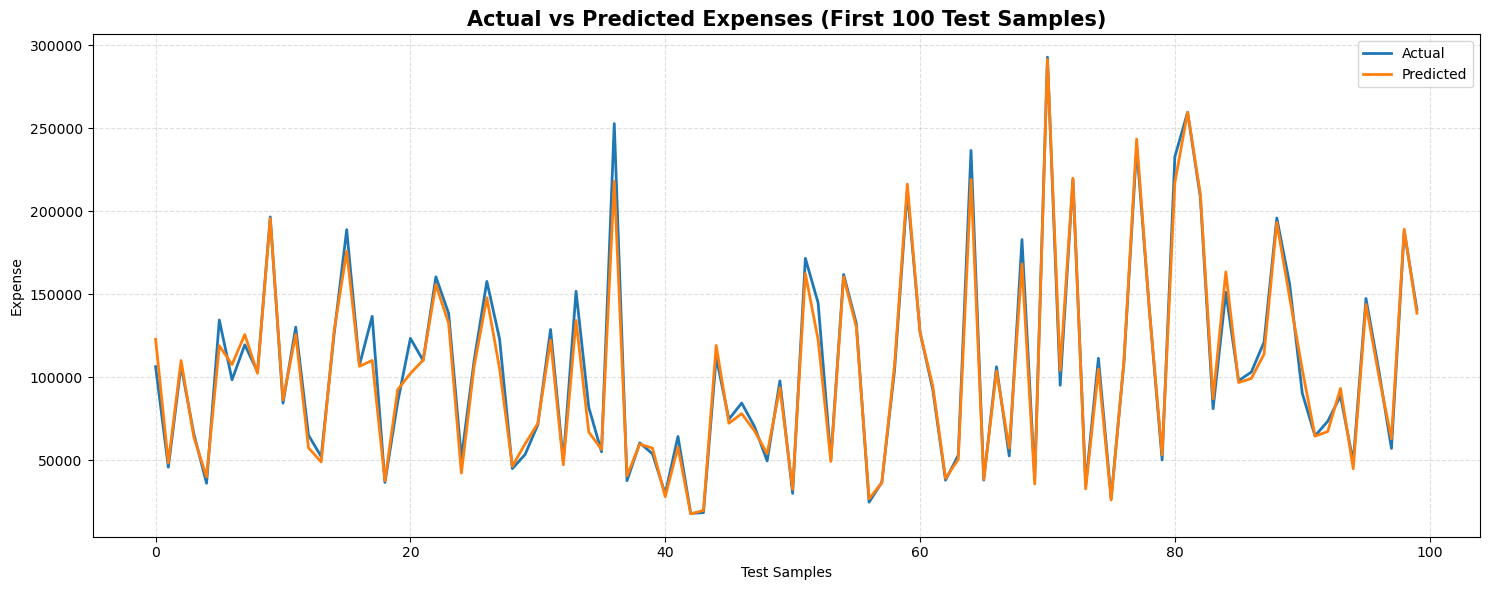

In [40]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions

})

comparison = comparison.reset_index(drop=True)

comparison = comparison.iloc[:100]

plt.figure(figsize=(15,6))

plt.plot(

    comparison.index,

    comparison["Actual"],

    linewidth=2,

    label="Actual"

)

plt.plot(

    comparison.index,

    comparison["Predicted"],

    linewidth=2,

    label="Predicted"

)

plt.title(

    "Actual vs Predicted Expenses (First 100 Test Samples)",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Test Samples")

plt.ylabel("Expense")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(

    "prediction_line_plot.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

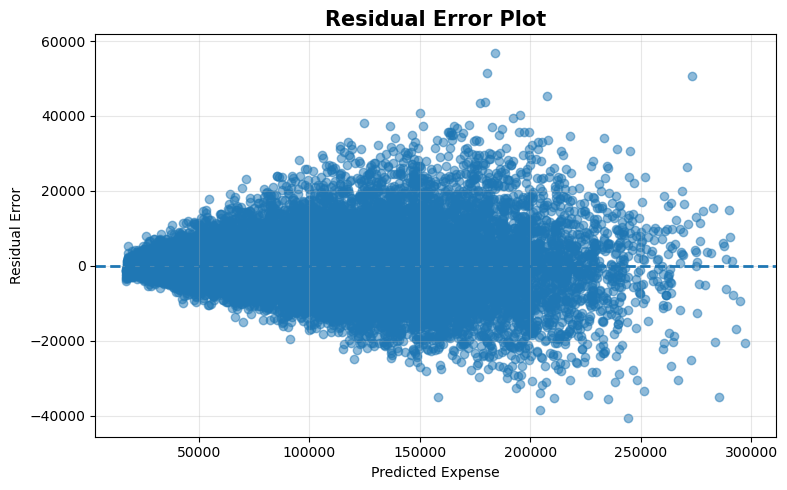

In [41]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

plt.scatter(

    predictions,

    residuals,

    alpha=0.5

)

plt.axhline(

    y=0,

    linestyle="--",

    linewidth=2

)

plt.title(

    "Residual Error Plot",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Predicted Expense")

plt.ylabel("Residual Error")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    "residual_plot.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [42]:
print(results_df)

results_df.to_csv(

    "model_comparison.csv",

    index=False

)

               Model          MAE         RMSE        R²      MAPE
3      Tuned XGBoost  5381.844142  7701.694127  0.978836  5.301868
1  Gradient Boosting  5397.078935  7731.030196  0.978675  5.303749
2            XGBoost  5407.350480  7740.329321  0.978623  5.318291
0      Random Forest  5542.312876  7892.317657  0.977776  5.456832


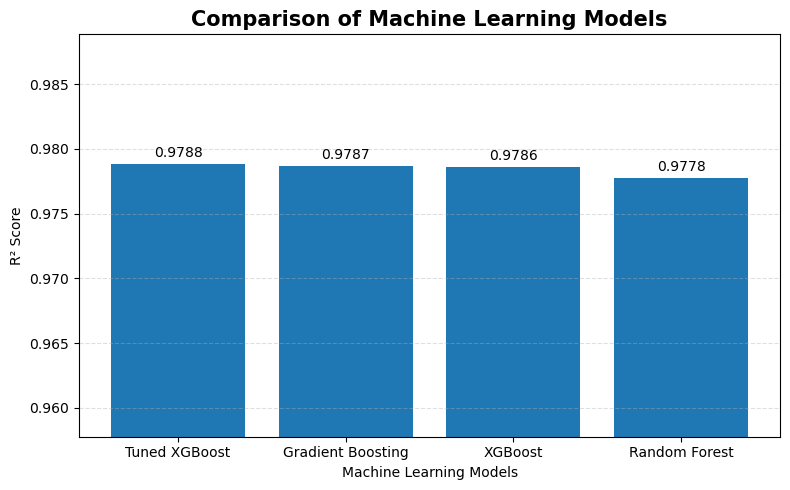

In [43]:
plt.figure(figsize=(8,5))

bars = plt.bar(

    results_df["Model"],

    results_df["R²"]

)

plt.ylabel("R² Score")

plt.xlabel("Machine Learning Models")

plt.title(

    "Comparison of Machine Learning Models",

    fontsize=15,

    fontweight="bold"

)

plt.ylim(

    results_df["R²"].min()-0.02,

    results_df["R²"].max()+0.01

)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x()+bar.get_width()/2,

        height+0.0005,

        f"{height:.4f}",

        ha="center"

    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(

    "model_comparison_r2.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [44]:
importance.to_csv(

    "feature_importance.csv",

    index=False

)

results_df.to_csv(

    "model_comparison.csv",

    index=False

)

print("All evaluation files saved successfully!")

All evaluation files saved successfully!


In [1]:
import joblib
import pandas as pd

# Load trained model
model = joblib.load(
    "expense_prediction_model.pkl"
)

# Load feature names
feature_names = joblib.load(
    "feature_names.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [2]:
dummy = pd.DataFrame(
    columns=feature_names
)

In [3]:
user1 = {col:0 for col in feature_names}

user1.update({

    "Year":2026,

    "Month":8,

    "Monthly_Income":85000,

    "Bills":12000,

    "Education":4000,

    "Entertainment":3000,

    "Food":18000,

    "Health":2500,

    "Shopping":5000,

    "Transport":6000,

    "Travel":3000,

    "Total_Expense":53500,

    "Savings":31500,

    "Savings_Rate":37.06,

    "Expense_Ratio":62.94,

    "Average_Daily_Expense":1775,

    "Weekend_Spending_Percentage":34,

    "Transaction_Count":68

})

user1["Spending_Profile"] = 1

dummy.loc[0] = user1

In [4]:
user1 = {col:0 for col in feature_names}

user1.update({

    "Year":2026,

    "Month":8,

    "Monthly_Income":85000,

    "Bills":12000,

    "Education":4000,

    "Entertainment":3000,

    "Food":18000,

    "Health":2500,

    "Shopping":5000,

    "Transport":6000,

    "Travel":3000,

    "Total_Expense":53500,

    "Savings":31500,

    "Savings_Rate":37.06,

    "Expense_Ratio":62.94,

    "Average_Daily_Expense":1775,

    "Weekend_Spending_Percentage":34,

    "Transaction_Count":68

})

user1["Spending_Profile"] = 1

dummy.loc[0] = user1

In [5]:
user2 = {col:0 for col in feature_names}

user2.update({

    "Year":2026,

    "Month":8,

    "Monthly_Income":180000,

    "Bills":30000,

    "Education":7000,

    "Entertainment":9000,

    "Food":35000,

    "Health":6000,

    "Shopping":12000,

    "Transport":9000,

    "Travel":10000,

    "Total_Expense":118000,

    "Savings":62000,

    "Savings_Rate":34.44,

    "Expense_Ratio":65.56,

    "Average_Daily_Expense":3900,

    "Weekend_Spending_Percentage":41,

    "Transaction_Count":122

})

user2["Spending_Profile"] = 2

dummy.loc[1] = user2

In [6]:
user3 = {col:0 for col in feature_names}

user3.update({

    "Year":2026,

    "Month":8,

    "Monthly_Income":450000,

    "Bills":70000,

    "Education":12000,

    "Entertainment":25000,

    "Food":65000,

    "Health":10000,

    "Shopping":40000,

    "Transport":18000,

    "Travel":30000,

    "Total_Expense":270000,

    "Savings":180000,

    "Savings_Rate":40,

    "Expense_Ratio":60,

    "Average_Daily_Expense":9000,

    "Weekend_Spending_Percentage":45,

    "Transaction_Count":248

})

user3["Spending_Profile"] = 3

dummy.loc[2] = user3

In [7]:
predictions = model.predict(dummy)

dummy["Predicted_NextMonthExpense"] = predictions

In [8]:
result = dummy[[

    "Monthly_Income",

    "Total_Expense",

    "Savings",

    "Predicted_NextMonthExpense"

]]

print(result)

   Monthly_Income  Total_Expense  Savings  Predicted_NextMonthExpense
0           85000          53500    31500                54856.859375
1          180000         118000    62000               123852.820312
2          450000         270000   180000               291501.218750


In [9]:
result.to_csv(

    "prediction_results.csv",

    index=False

)

print("Prediction Results Saved")

Prediction Results Saved


In [ ]:
single_user = dummy.iloc[[0]]

prediction = model.predict(single_user)

print("Predicted Next Month Expense")

print("Rs.", round(prediction[0],2))